In [1]:
import os
from pathlib import Path
import time
from copy import deepcopy

from tqdm import trange, tqdm

import cantera as ct
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.decomposition import PCA, IncrementalPCA

from chem_operator.utils import get_mechanism_file, to_numpy
from chem_operator.datasets import (
    CaseParameters, CaseSimulator, SimulationRecord, SimulationDatasetGenerator, CanteraDataset    
)

import torch

from dataset_generator import CSTRCaseSimulator

prog_path = Path(os.path.abspath(""))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running Cantera version: {ct.__version__}")

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


Running Cantera version: 3.2.0


In [2]:
dataset = CanteraDataset(
    path=prog_path.parent.parent / "datasets" / "cstr" / "cstr_train.h5",
    full_trajectory_mode=True,
    dtype=torch.float32
    # n_steps_input=n_steps_input,
    # n_steps_output=n_steps_output,
    # dt_stride=dt_stride,
    # state_variables=state_variables,
    # time_key=time_key,
    # trajectory_parameters=trajectory_parameters,
)

# DataLoader(
#     dataset,
#     batch_size=batch_size,
#     shuffle=shuffle,
#     **kwargs,
# )
len(dataset)

16

In [7]:
gas = ct.Solution(get_mechanism_file(dataset["metadata"]["mechanism"]))

TypeError: list indices must be integers or slices, not str

In [14]:
def get_species_names(sample, gas=None):
    # if "species_names" in sample.get("metadata", {}):
    #     return list(sample["metadata"]["species_names"])

    if gas is not None:
        return list(gas.species_names)

    mechanism = sample.get("metadata", {}).get("mechanism")
    if mechanism is None:
        raise ValueError("Need `gas=ct.Solution(...)` or metadata['mechanism'].")

    gas = ct.Solution(get_mechanism_file(mechanism))
    return list(gas.species_names)

In [12]:
sample = dataset[0]

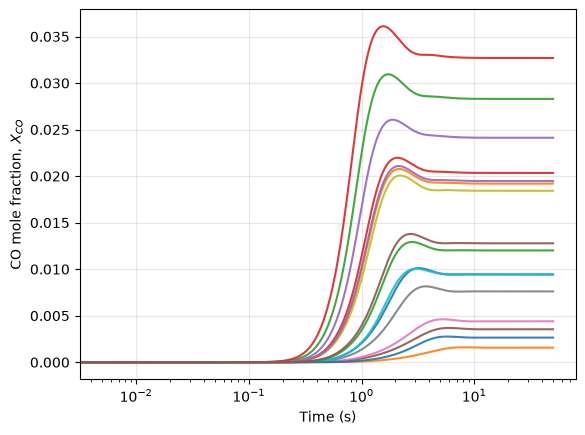

In [19]:
fig, ax = plt.subplots() # figsize=(8, 5)

for i in range(len(dataset)):
    sample = dataset[i]

    species_names = get_species_names(sample)
    co_idx = species_names.index("CO")

    t_out = to_numpy(sample["output_coordinates"]["time"])
    x_out = to_numpy(sample["output_fields"]["X"])[:, co_idx]

    t_in = to_numpy(sample["input_coordinates"]["time"]).reshape(-1)
    x_in = to_numpy(sample["input_fields"]["X"])[:, co_idx].reshape(-1)

    t = np.concatenate([t_in, t_out])
    x_co = np.concatenate([x_in, x_out])

    ax.semilogx(t, x_co, alpha=0.9) # linewidth=2

ax.set_xlabel("Time (s)")
ax.set_ylabel(r"CO mole fraction, $X_{CO}$")
# ax.set_title(f"CO mole fraction across time for {n} states")
ax.grid(True, alpha=0.3)

In [ ]:
dataset[0]["input_fields"]["X"].dtype

torch.float32

In [23]:
print(ct.get_data_directories())
gas = ct.Solution("methane_pox_on_pt.yaml")
gas.species_names

['.', '/home/rohan/SURF/experiment-v2/.venv/lib/python3.12/site-packages/cantera/data']


['H2', 'O2', 'H2O', 'CH4', 'CO', 'CO2', 'AR']

In [ ]:
gas = ct.Solution(get_mechanism_file(dataset[0]["metadata"]["mechanism"]))

In [ ]:
for i in trange(len(dataset)):
    # print(dataset[i]["input_fields"]["X"])
    # print()
    ipca.partial_fit(
        dataset[i]["output_fields"]["X"]

In [ ]:
# need to normalize first

ipca = IncrementalPCA(
    n_components=10,
)
for i in trange(len(dataset)):
    # print(dataset[i]["input_fields"]["X"])
    # print()
    ipca.partial_fit(
        dataset[i]["output_fields"]["X"]
        .detach()
        .cpu()
        .numpy()
        .astype(np.float32, copy=False)
    )

  0%|          | 0/16 [00:00<?, ?it/s]

100%|██████████| 16/16 [02:44<00:00, 10.29s/it]


In [ ]:
ipca.explained_variance_ratio_

array([9.73799816e-01, 2.45475879e-02, 9.58098944e-04, 1.44426475e-04,
       7.04295038e-05, 1.20877731e-05, 4.35165346e-06, 2.27046748e-06,
       7.02093620e-07, 3.55824146e-07])